# 12. Learned embeddings

Every other page here measures cells with CellProfiler: named features, one per shape or intensity or texture,
in a `var` that says which compartment and which channel each came from. A learned embedding replaces that
block with the output of a neural network — a few hundred numbers per well that mean nothing individually.

mantispy does not care. `X` is a matrix, and normalization, hit calling, consensus and the metrics all run on
one as readily as the other. What changes is the recipe around it, and what you can no longer ask.

This page uses JUMP-Lite {cite:p}`Munoz_2026`, which is built for exactly this comparison: four plates of the
JUMP Target-2 plate map, one from each of four laboratories, with **the same 1,536 wells** measured six ways —
five learned embeddings and one CellProfiler-equivalent feature set. The rows and the metadata are identical
across all six, so swapping the feature block is a controlled experiment rather than a change of dataset.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

import mantispy as mt

adata = mt.ds.jump_lite("openphenom")
adata

/Users/tim.treis/Library/Application Support/hatch/env/virtual/mantispy/lPd87khm/tutorials/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 1536 × 384
    obs: 'Metadata_id', 'Metadata_Source', 'Metadata_Batch', 'Metadata_Plate', 'Metadata_Well', 'Metadata_Site', 'Metadata_model', 'Metadata_dataset', 'Metadata_compression', 'Metadata_CellCount', 'Metadata_JCP2022', 'Metadata_InChIKey', 'Metadata_Perturbation', 'Metadata_Control'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature'
    uns: 'mantispy'
    layers: None (.X)

384 numbers per well from OpenPhenom, a Cell Painting foundation model. The metadata is ordinary JUMP
metadata — source, batch, plate, well, and the compound each well received.

The four batches are four different laboratories running one plate map, which makes this a batch-correction
problem with a clean design: whatever separates `source_3` from `source_6` is not biology, because they
received the same compounds in the same wells.

In [2]:
counts = adata.obs.groupby("Metadata_Source", observed=True).agg(
    plates=("Metadata_Plate", "nunique"), wells=("Metadata_Well", "size"), controls=("Metadata_Control", "sum")
)
counts["compounds"] = adata.obs.groupby("Metadata_Source", observed=True)["Metadata_Perturbation"].nunique()
counts

,plates,wells,controls,compounds
Metadata_Source,,,,
source_3,1,384,64,302
source_4,1,384,64,302
source_5,1,384,64,302
source_6,1,384,64,302


## What `var` no longer tells you

A CellProfiler feature name parses into a compartment, a feature group and a channel. `openphenom_nahualX_17`
has neither. The loader supplies the annotation columns the schema requires and leaves them empty, rather
than letting the CellProfiler name parser loose on names with no structure in them — that parser reads
`openphenom_nahualX_17` as the `nahualX` group of an `openphenom` object, and the screen would quietly
acquire feature families named after the model's own tensors.

In [3]:
adata.var.head(3)

,object,feature_group,feature,channel,scale,angle,gray_levels,radial_bin,params,is_feature
openphenom_nahualX_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
openphenom_nahualX_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
openphenom_nahualX_10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True


This is not a defect, it is the honest answer: the embedding has no notion of a channel or a compartment. The
consequence is that anything keyed on the feature annotation has nothing to work with. `pl.effect_sizes`
colours its bars by feature family, `tl.feature_sets` groups features into sets, and the CellProfiler
blocklist names features to drop — none of them apply here.

What survives is everything that treats a feature as an anonymous number: normalization, sphering, distances,
hit calling, consensus, and every metric.

## Bringing your own embedding

`ds.jump_lite` is a convenience. An embedding you produced yourself is a matrix and a metadata frame, and
`io.stamp` is what puts it on the mantispy API surface.

In [4]:
import anndata as ad

# Pretend this came out of your own model, one row per well.
values = np.asarray(adata.X)[:8]
metadata = adata.obs[["Metadata_Plate", "Metadata_Well", "Metadata_Perturbation", "Metadata_Control"]][:8]

mine = ad.AnnData(values, obs=metadata.copy())
mine.var_names = [f"mymodel_{index}" for index in range(values.shape[1])]
mt.io.stamp(mine, resolution="well")
mt.io.validate(mine)

ValidationReport(ok=True, errors=0, warnings=1)

`io.stamp` supplies the annotation columns empty rather than parsing the feature names, and records
the resolution, so the object validates and can be written to h5ad. Supplying them empty is the point:
the parser would read `mymodel_17` as structure it does not have. It refuses
a resolution whose required `obs` columns are missing rather than letting the failure surface three calls later.

## The recipe

Two things change against the CellProfiler pipeline.

**Normalize as usual.** The embedding is the model's raw output on each well's images: it carries the plate's
staining and illumination just as CellProfiler features do, so a per-plate normalization against the negative
controls is still the first step. The degenerate-scale check still applies, and here it is worth running for
what it reports rather than what it drops: none of these embedding dimensions is constant among a plate's
controls, while the `cp_measure` feature set below has more than a hundred features that are.

**Do not select features.** Variance and correlation filters assume features are interpretable measurements
that can be dropped individually. The dimensions of an embedding are a basis, not a list of measurements;
dropping some of them because they correlate discards the geometry the model learned.

In [5]:
mt.pp.normalize(adata, method="mad_robustize", by="Metadata_Plate", reference="negcon")
degenerate = int(adata.var["degenerate_scale"].sum())
adata = adata[:, ~adata.var["degenerate_scale"].to_numpy()].copy()

# The same check on the CellProfiler-equivalent set, which is what makes the number worth reporting.
classical = mt.ds.jump_lite("cp_measure")
mt.pp.normalize(classical, method="mad_robustize", by="Metadata_Plate", reference="negcon")

report = {
    "openphenom: constant among a plate's controls": f"{degenerate} of {adata.n_vars}",
    "cp_measure: constant among a plate's controls": (
        f"{int(classical.var['degenerate_scale'].sum())} of {classical.n_vars}"
    ),
}
del classical
report

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_83086/3906305423.py:7: UserWarning: 30 of 2550 features have no reference values to centre on in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon', because every value there is missing or infinite. Their centre is set to 0 where it is missing and their scale to 1, so the values measured outside the reference rows pass through unnormalized instead of becoming NaN, and are not comparable across groups. They are flagged in var['degenerate_scale']; drop them with adata = adata[:, ~adata.var['degenerate_scale']].copy().
  mt.pp.normalize(classical, method="mad_robustize", by="Metadata_Plate", reference="negcon")
/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_83086/3906305423.py:7: UserWarning: 103 of 2550 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so t

{"openphenom: constant among a plate's controls": '0 of 384',
 "cp_measure: constant among a plate's controls": '133 of 2550'}

## Comparing six feature sets

The interesting question is not whether an embedding works, but how it compares with the alternatives on the
same wells. Two readouts, both of which the package computes:

- **`metrics.known_relationships`** — of the compounds annotated to act on the same gene, how many end up in
  either tail of the similarity distribution? A map with no information recovers 10%.
- **`tl.percent_replicating`** — does a compound's profile match its own replicates, run at another laboratory?

Each is measured under three alignments: the principal components alone, `pp.tvn`, and `pp.harmony`, which
ranked top-three in every scenario of the batch-correction benchmark {cite:p}`Arevalo_2024` and is the last step
of the JUMP recipe. `pp.harmony` needs the optional extra, `pip install 'mantispy[harmony]'`.

They measure different things, and as the table below shows they do not agree.

In [6]:
targets = mt.ds.jump_lite_targets()
f"{targets['source'].nunique()} genes over {targets['target'].nunique()} compounds"

'1300 genes over 1526 compounds'

In [7]:
def prepared(model):
    """Load one feature set, normalize it on the controls, and drop what cannot be normalized."""
    wells = mt.ds.jump_lite(model)
    mt.pp.normalize(wells, method="mad_robustize", by="Metadata_Plate", reference="negcon")
    wells = wells[:, ~wells.var["degenerate_scale"].to_numpy()].copy()
    if np.isnan(np.asarray(wells.X)).any():  # cp_measure carries features that are missing outright
        mt.pp.feature_select(wells, operations=("drop_na_columns",), na_cutoff=0.0)
        wells = mt.pp.subset_features(wells)
    sc.pp.pca(wells, n_comps=50)
    mt.pp.tvn(wells, batch_key="Metadata_Source", use_rep="X_pca", key_added="X_tvn")
    mt.pp.harmony(wells, batch_key="Metadata_Source", use_rep="X_pca", key_added="X_harmony")
    return wells


def scored(wells, rep):
    """Target recall on consensus profiles, and replicate retrieval on wells."""
    treated = ~wells.obs["Metadata_Control"].to_numpy()
    profiles = ad.AnnData(np.asarray(wells.obsm[rep], dtype=np.float32)[treated], obs=wells.obs[treated].copy())
    mt.io.stamp(profiles, resolution="well")
    recall = mt.metrics.known_relationships(mt.tl.consensus(profiles, method="median", min_replicates=1), targets)

    mt.tl.percent_replicating(profiles, groupby="Metadata_Perturbation", use_rep=None, null_size=2000, seed=0)
    replicating = profiles.uns["mantispy"]["percent_replicating"]["is_replicating"].mean()
    return float(recall["value"].iloc[0]), float(replicating)


rows, density = [], []
for model in mt.ds.JUMP_LITE_MODELS:
    wells = prepared(model)
    if model == "openphenom":
        embedding = wells  # kept for the sections below, which all work on this one
    density.append(
        {
            "model": model,
            "cell count": float(
                mt.metrics.pc_regression(wells, key="Metadata_CellCount", use_rep="X_pca")["value"].iloc[0]
            ),
            "source": float(mt.metrics.pc_regression(wells, key="Metadata_Source", use_rep="X_pca")["value"].iloc[0]),
        }
    )
    for rep in ("X_pca", "X_tvn", "X_harmony"):
        recall, replicating = scored(wells, rep)
        rows.append(
            {
                "model": model,
                "alignment": rep,
                "target recall": recall,
                "percent replicating": replicating,
                "source variance": float(
                    mt.metrics.pc_regression(wells, key="Metadata_Source", use_rep=rep)["value"].iloc[0]
                ),
            }
        )

comparison = pd.DataFrame(rows)
comparison.pivot(index="model", columns="alignment", values=["target recall", "percent replicating"]).round(3)

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_83086/1832414345.py:4: UserWarning: 30 of 2550 features have no reference values to centre on in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon', because every value there is missing or infinite. Their centre is set to 0 where it is missing and their scale to 1, so the values measured outside the reference rows pass through unnormalized instead of becoming NaN, and are not comparable across groups. They are flagged in var['degenerate_scale']; drop them with adata = adata[:, ~adata.var['degenerate_scale']].copy().
  mt.pp.normalize(wells, method="mad_robustize", by="Metadata_Plate", reference="negcon")
/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_83086/1832414345.py:4: UserWarning: 103 of 2550 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they 

target recall               percent replicating              
alignment         X_harmony  X_pca  X_tvn           X_harmony  X_pca  X_tvn
model                                                                      
cp_measure            0.037  0.030  0.127               0.412  0.409  0.339
dinov2                0.052  0.052  0.104               0.508  0.439  0.355
dinov2_random         0.109  0.114  0.087               0.086  0.080  0.106
morphem               0.052  0.069  0.136               0.542  0.392  0.399
openphenom            0.069  0.057  0.127               0.445  0.352  0.316
subcell               0.055  0.042  0.154               0.502  0.435  0.329

Three things to read out of that table.

**The untrained model behaves like one.** `dinov2_random` is the same architecture with random weights, and it
is the control for this whole comparison: its replicate retrieval collapses, because random projections of an
image do not reproduce across laboratories. Its target recall sits near the 10% baseline, and it stays there
under every alignment — no correction manufactures structure out of noise. Any pipeline that reports a trained
model doing no better than this one has a bug, not a finding.

**No alignment wins on both readouts.** `pp.harmony` gives the best replicate retrieval of the three on every
trained feature set, and leaves target recall at or below chance. `pp.tvn` does the opposite: it is the only
one that lifts target recall above the 10% baseline, and it costs replicate retrieval on four of the six.
They optimize different things — Harmony mixes the batches in each local neighbourhood, while TVN aligns each
batch's control covariance to the pooled one — and on this screen neither buys the other's gain. Which one to
use is a decision about what the screen is for, not a default.

**The CellProfiler-equivalent set is not behind.** `cp_measure` is competitive with the learned models on both
readouts here. The independent benchmark of these six reaches the same conclusion {cite:p}`Munoz_2026`: on
Cell Painting, classical features remain a strong baseline, and the case for an embedding is throughput and the
absence of a segmentation step rather than a large accuracy gain.

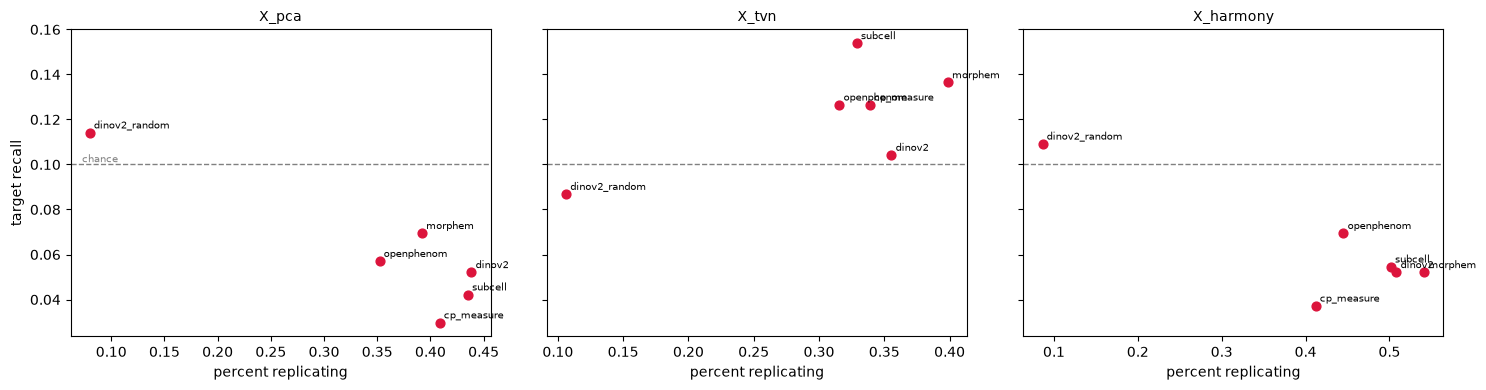

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, alignment in zip(axes, ("X_pca", "X_tvn", "X_harmony"), strict=True):
    block = comparison[comparison["alignment"] == alignment].set_index("model")
    ax.scatter(block["percent replicating"], block["target recall"], s=40, color="crimson")
    for model, row in block.iterrows():
        ax.annotate(
            model,
            (row["percent replicating"], row["target recall"]),
            fontsize=7,
            xytext=(3, 3),
            textcoords="offset points",
        )
    ax.axhline(0.10, color="grey", ls="--", lw=1)
    ax.set_title(alignment, fontsize=10)
    ax.set_xlabel("percent replicating")
axes[0].set_ylabel("target recall")
axes[0].text(0.02, 0.10, " chance", fontsize=7, color="grey", va="bottom", transform=axes[0].get_yaxis_transform())
fig.tight_layout()
plt.show()

The dashed line is the 10% a map with no information recovers.

## Do the laboratories still separate?

The same `metrics.pc_regression`, now on the source, and it separates the two alignments sharply.

In [9]:
comparison.pivot(index="model", columns="alignment", values="source variance").round(3)

alignment,X_harmony,X_pca,X_tvn
model,,,
cp_measure,0.005,0.002,0.003
dinov2,0.006,0.030,0.045
dinov2_random,0.002,0.019,0.010
morphem,0.007,0.044,0.042
openphenom,0.005,0.035,0.036
subcell,0.007,0.034,0.027


Harmony takes it to roughly half a percent on every feature set. TVN leaves it where it was, and on some
sets slightly higher — which is consistent with what the two do, since aligning the second moments of each
batch's controls is not the same as mixing the batches in every neighbourhood.

Read this together with the table above, not instead of it: a correction that leaves the batch structure intact
has done nothing, and one that removes it may have taken the biology with it.

## What the first component actually is

Everything above treats the laboratory as the nuisance to correct. Ask what else the embedding is spending its
variance on, using the same `pc_regression` and the cell count each well already carries.

In [10]:
pd.DataFrame(density).set_index("model").round(3)

,cell count,source
model,,
openphenom,0.323,0.035
dinov2,0.376,0.030
dinov2_random,0.015,0.019
subcell,0.216,0.034
morphem,0.301,0.044
cp_measure,0.003,0.002


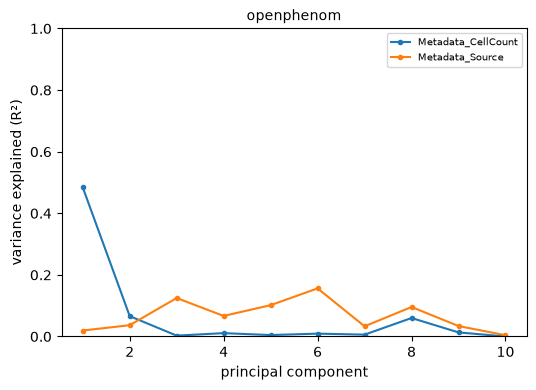

In [11]:
ax = mt.pl.batch_variance(embedding, keys=["Metadata_CellCount", "Metadata_Source"], use_rep="X_pca", n_comps=10)
ax.set_title("openphenom", fontsize=10)
plt.show()

Across the four trained embeddings the cell count explains six to thirteen times more of the variance than
the laboratory does, and the per-component plot says where: it is the first principal component, while the
laboratory is spread thinly over several later ones. Two controls in that table say what the axis is:

- **`dinov2_random`, untrained, does not do it.** So it is not an artefact of the pipeline or of the images —
  the trained models *learned* to encode how full the well is.
- **`cp_measure` does not do it either.** CellProfiler-style features are per-cell measurements averaged over a
  well, and averaging is what removes the dependence on how many cells there were. An embedding of the whole
  field keeps it.

For a page about swapping the feature block, that is the difference that matters most. It is also why the
alignment methods moved target recall so little: they were correcting the second-largest axis.

### So should the thin wells go?

The reflex is a floor under the cell count. Before reaching for it, look at which wells it removes.

In [12]:
raw = mt.ds.jump_lite("openphenom")
cell_counts = raw.obs["Metadata_CellCount"].to_numpy(dtype=float)
thin = cell_counts < 25
by_compound = raw.obs.assign(thin=thin).groupby("Metadata_Perturbation", observed=True)["thin"].sum()

{
    "wells under 50 cells": int((cell_counts < 50).sum()),
    "of which controls": int(raw.obs["Metadata_Control"].to_numpy()[cell_counts < 50].sum()),
    "wells under 25 cells": int(thin.sum()),
    "compounds thin at 2+ of the 4 laboratories": int((by_compound >= 2).sum()),
    "share of thin wells belonging to those": f"{by_compound[raw.obs['Metadata_Perturbation'][thin]].ge(2).mean():.0%}",
}

{'wells under 50 cells': 139,
 'of which controls': 2,
 'wells under 25 cells': 55,
 'compounds thin at 2+ of the 4 laboratories': 16,
 'share of thin wells belonging to those': '76%'}

Almost none are control wells, and most belong to compounds that come out thin at more than one laboratory
independently. That is not a plate that failed, it is cytotoxicity: the compound killed the cells, reproducibly.
A cell-count floor would delete the compounds with the largest effects.

It does not follow that the thin wells carry usable signal. Compare, within each stratum, how much more alike
two wells of the *same* compound are than two wells of different ones.

In [13]:
wells = embedding  # the same object the comparison above built
mt.tl.similarity(wells, metric="cosine", use_rep="X_pca")
matrix = np.asarray(wells.obsp["similarity"], dtype=float)
np.fill_diagonal(matrix, np.nan)

compound = wells.obs["Metadata_Perturbation"].astype(str).to_numpy()
well_counts = wells.obs["Metadata_CellCount"].to_numpy(dtype=float)
treated = ~wells.obs["Metadata_Control"].to_numpy()

gaps = []
for label, keep in (
    ("thin (<50 cells)", treated & (well_counts < 50)),
    ("normal (50+)", treated & (well_counts >= 50)),
):
    rows = np.flatnonzero(keep)
    block = matrix[np.ix_(rows, rows)]
    same = compound[rows][:, None] == compound[rows][None, :]
    gaps.append(
        {
            "wells": label,
            "n": rows.size,
            "same compound": np.nanmedian(block[same]),
            "different": np.nanmedian(block[~same]),
        }
    )
gaps = pd.DataFrame(gaps).set_index("wells")
gaps["gap"] = gaps["same compound"] - gaps["different"]
gaps.round(3)

,n,same compound,different,gap
wells,,,,
thin (<50 cells),137,0.712,0.651,0.062
normal (50+),1143,0.751,0.519,0.232


Among the thin wells that gap nearly closes: two thin wells of *different* compounds look almost as alike as
two wells of the same one. Whatever they reproduce, it is mostly emptiness, not the compound.

So both readings were half right. The wells are real biology — cytotoxicity — and their profiles are
nonetheless dominated by density. Measure the two obvious remedies rather than choosing one on principle.

In [14]:
def treated_pipeline(treatment):
    """The same recipe, with a cell-count floor or with the count regressed out."""
    wells = mt.ds.jump_lite("openphenom")
    if treatment == "floor":
        wells = wells[wells.obs["Metadata_CellCount"].to_numpy(dtype=float) >= 50].copy()
    mt.pp.normalize(wells, method="mad_robustize", by="Metadata_Plate", reference="negcon")
    wells = wells[:, ~wells.var["degenerate_scale"].to_numpy()].copy()
    if treatment == "regress":
        mt.pp.regress_out(wells, keys=("Metadata_CellCount",), by="Metadata_Plate")
    sc.pp.pca(wells, n_comps=50)
    mt.pp.tvn(wells, batch_key="Metadata_Source", use_rep="X_pca", key_added="X_tvn")
    mt.pp.harmony(wells, batch_key="Metadata_Source", use_rep="X_pca", key_added="X_harmony")
    return wells


remedies = []
for treatment in ("none", "floor", "regress"):
    trial = treated_pipeline(treatment)
    density_left = float(mt.metrics.pc_regression(trial, key="Metadata_CellCount", use_rep="X_pca")["value"].iloc[0])
    for rep in ("X_pca", "X_tvn", "X_harmony"):
        recall, replicating = scored(trial, rep)
        remedies.append(
            {
                "treatment": treatment,
                "alignment": rep,
                "wells": trial.n_obs,
                "cell count variance": density_left,
                "target recall": recall,
                "percent replicating": replicating,
            }
        )
pd.DataFrame(remedies).set_index(["treatment", "alignment"]).round(3)

wells  cell count variance  target recall  \
treatment alignment                                              
none      X_pca       1536                0.323          0.057   
          X_tvn       1536                0.323          0.127   
          X_harmony   1536                0.323          0.069   
floor     X_pca       1397                0.250          0.048   
          X_tvn       1397                0.250          0.152   
          X_harmony   1397                0.250          0.048   
regress   X_pca       1536                0.064          0.127   
          X_tvn       1536                0.064          0.161   
          X_harmony   1536                0.064          0.117   

                     percent replicating  
treatment alignment                       
none      X_pca                    0.352  
          X_tvn                    0.316  
          X_harmony                0.445  
floor     X_pca                    0.300  
          X_tvn                    0.286  
          X_harmony                0.336  
regress   X_pca                    0.103  
          X_tvn                    0.292  
          X_harmony                0.193

Regressing the count out does what it says: it takes the density axis down, and target recall goes up under
every alignment, because the axis it was competing with is gone. What it costs depends on where you look — TVN
gives up little replicate retrieval, while the unaligned embedding and Harmony give up a great deal of it,
which is a reminder that these two readouts were never measuring the same thing.

That is the trade, and it is the reason to stop rather than to pick a winner. For a **compound** screen the
cell count is partly a *treatment effect* — the compound killed the cells — so regressing it out removes part
of the phenotype, not just a nuisance. The JUMP recipe reflects exactly this: it regresses the cell count out
of the ORF and CRISPR arms, whose plate layouts were not randomized, and does not do it for compounds
{cite:p}`Chandrasekaran_2023`.

So this page keeps every well and does not regress, which is now a decision rather than an omission. What to
do instead is ask the question directly: `tl.cytotoxicity` separates "this compound has a phenotype" from
"this compound killed the cells", which is the subject of
[8. Trustworthy features and experimental design](08_trustworthy_features_and_design.ipynb). Report the cell
count beside the readouts, and know that on an embedding it is the first thing the model sees.

One thing that does not transfer from single-cell work: scanpy's `sc.pp.filter_cells` and `sc.pp.filter_genes`
threshold on counts, and a morphological profile has no counts — after normalization its rows sum to roughly
zero, so those filters are meaningless here rather than merely unhelpful. The scanpy that does apply is the
part already used on this page: `sc.pp.pca`, `sc.pp.neighbors` and `sc.tl.umap`, which work because the object
is an ordinary `AnnData`.

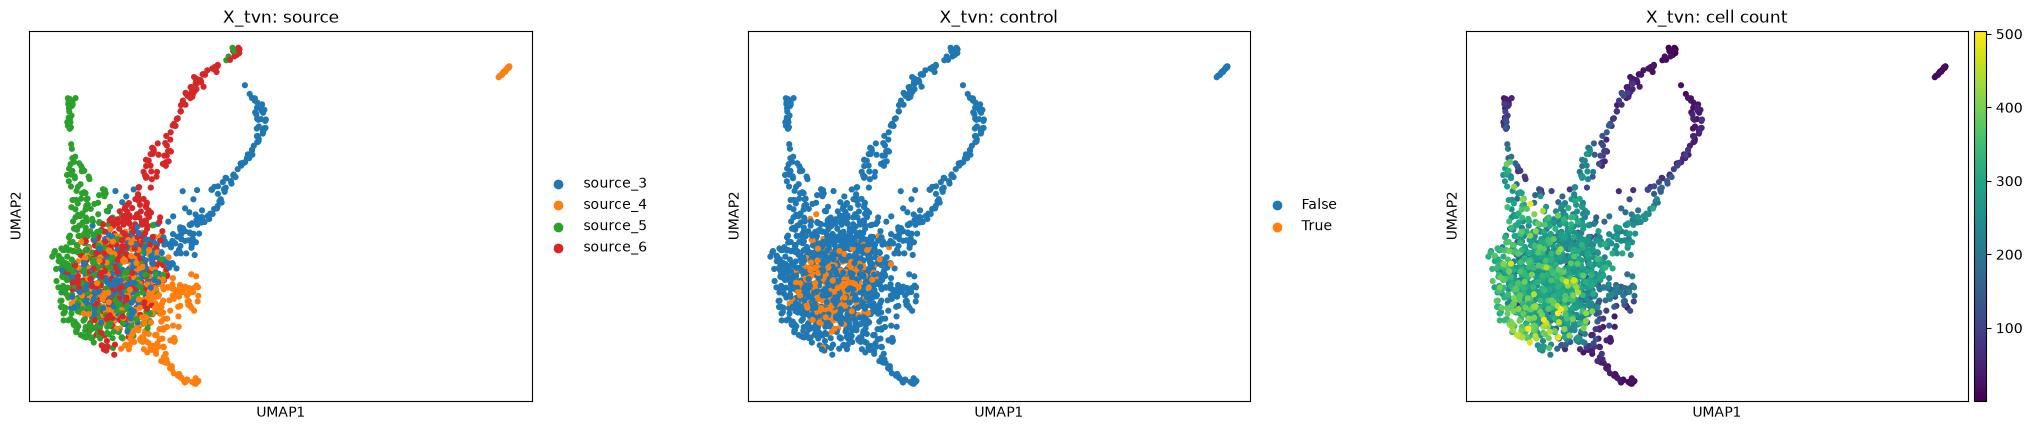

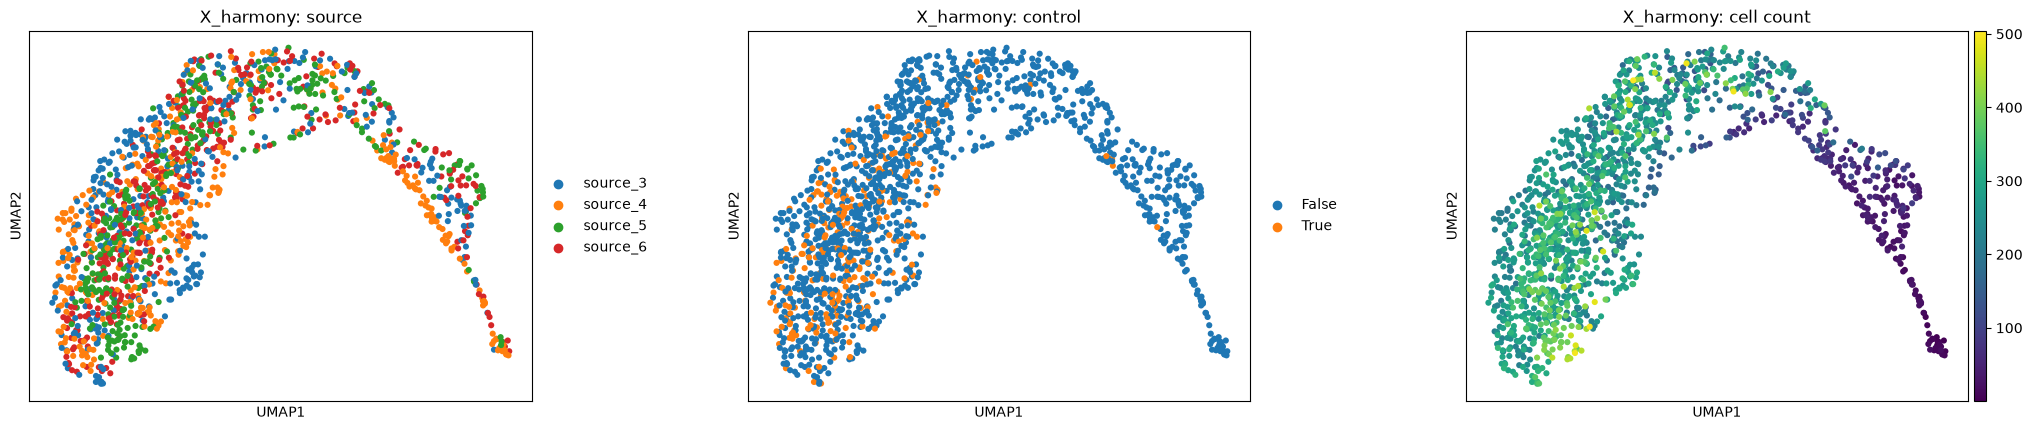

In [15]:
for rep in ("X_tvn", "X_harmony"):
    sc.pp.neighbors(wells, use_rep=rep)
    sc.tl.umap(wells)
    wells.obsm[f"X_umap_{rep}"] = wells.obsm["X_umap"]
    sc.pl.umap(
        wells,
        color=["Metadata_Source", "Metadata_Control", "Metadata_CellCount"],
        wspace=0.3,
        title=[f"{rep}: source", f"{rep}: control", f"{rep}: cell count"],
    )

In [16]:
# The island is not a separate component of the neighbour graph, so name it by clustering.
sc.pp.neighbors(wells, use_rep="X_tvn")
sc.tl.leiden(wells, key_added="tvn_cluster", flavor="igraph", n_iterations=2, directed=False)

counts = wells.obs.groupby("tvn_cluster", observed=True)["Metadata_CellCount"].median()
island = wells.obs[wells.obs["tvn_cluster"] == counts.idxmin()]
{
    "wells in the emptiest cluster": len(island),
    "sources": island["Metadata_Source"].value_counts()[lambda s: s > 0].to_dict(),
    "controls among them": int(island["Metadata_Control"].sum()),
    "median cell count": float(island["Metadata_CellCount"].median()),
    "median elsewhere": float(wells.obs["Metadata_CellCount"].drop(island.index).median()),
}

{'wells in the emptiest cluster': 14,
 'sources': {'source_4': 14},
 'controls among them': 0,
 'median cell count': 11.5,
 'median elsewhere': 252.0}

The difference is visible rather than merely tabulated. Under TVN each source still throws off its own arm.
Under Harmony they interleave, which is what the source-variance number above already said.

The detached island in the TVN panel is worth chasing rather than explaining away, and the third panel already
says what it is: it is the dark end of the cell-count scale. Clustering the same graph names it — a handful of
wells, all from one laboratory, none of them controls, with a median cell count in the low teens against 252
everywhere else. They are nearly empty wells, and a profile averaged over a dozen cells is mostly noise. A
correction cannot fix that, and neither readout in the table above would have shown it to you: this is what
`pp.well_qc` and a cell count filter are for, and it is the argument for looking at the embedding as well as
the summary.

## Summary

- An embedding is a feature matrix. Normalization, distances, hit calling, consensus and every metric work on
  it unchanged; `io.stamp` brings one you produced yourself onto the API surface.
- `var` carries no compartment or channel, so feature families, feature sets and the blocklist do not apply.
  Read that as the embedding declining to answer, not as missing data.
- Normalize per plate against the controls as usual. Do not feature-select: the dimensions are a basis, not a
  list of measurements.
- Keep an untrained model in the comparison. It is the cheapest check that the pipeline measures anything.
- The alignments disagree. Harmony mixes the laboratories and improves replicate agreement; TVN is the only one
  that lifts recall of annotated targets above chance. Decide which the screen needs, measure both, and look at
  the embedding as well as the table.

Next: back to [8. Trustworthy features and experimental design](08_trustworthy_features_and_design.ipynb) for
the rest of the benchmarking vocabulary, or [4. Correcting and evaluating](04_correcting_and_evaluating.ipynb)
for the batch-correction methods this page compared TVN against.